# TA Features Experiment — Training

**Experiment goal**: Test whether adding back TA/Qlib-inspired features improves on the locked `lgbm_3class_xfn5d_30f` baseline.

**Baseline**: 30-feature locked model (artifact `lgbm_3class_xfn5d_30f_tuned-2026-04-22.pkl`)  
**Candidates**: 6 TA/Qlib features not currently in the model  
**Combos tested**: A (33f), B (34f), C (35f), D (36f)  
**Evaluation**: Same 7-fold expanding-window walk-forward, stride-5 offset averaging  
**Artifact**: Saved to `final_model_experiment/artifacts/` only — `final_model/` is untouched

> Run cells top-to-bottom. After reviewing Section 7 results, set `SAVE = True` in Section 8 **only if a combo beats the baseline on both ASA and Dir AUC**.

In [1]:
import sys, json, pickle, warnings
from pathlib import Path
from datetime import date
from itertools import product as iterproduct

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = Path('').resolve()
ROOT          = NOTEBOOK_DIR.parents[2]   # project root (3 levels up from final_model_experiment/)
EXP_PARENT    = ROOT / 'step3_predictive_model/model_experiments'
FINAL_ART_DIR = ROOT / 'step3_predictive_model/final_model/artifacts'
EXP_ART_DIR   = NOTEBOOK_DIR / 'artifacts'
EXP_ART_DIR.mkdir(exist_ok=True)

for p in [str(ROOT), str(EXP_PARENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f'ROOT            : {ROOT}')
print(f'Baseline arts   : {FINAL_ART_DIR}')
print(f'Experiment arts : {EXP_ART_DIR}')

ROOT            : /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis
Baseline arts   : /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis/step3_predictive_model/final_model/artifacts
Experiment arts : /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis/step3_predictive_model/model_experiments/final_model_experiment/artifacts


## 1. Load Baseline Config

In [2]:
# Load the locked artifact — only to read features / target / threshold / label maps
# The final_model/artifacts/ folder is NEVER written to in this notebook
locked_pkls = sorted(FINAL_ART_DIR.glob('lgbm_3class_xfn5d_30f_tuned-*.pkl'))
assert locked_pkls, f'Locked artifact not found in {FINAL_ART_DIR}'
with open(locked_pkls[-1], 'rb') as f:
    locked = pickle.load(f)

BASE_FEATURES = locked['features']      # the 30-feature list
TARGET        = locked['target']        # 'target_excess_xfn_5d'
THRESHOLD     = locked['threshold']     # 0.003
label_map     = locked['label_map']     # {-1:0, 0:1, 1:2}
inv_map       = locked['inverse_label_map']
LOCKED_PARAMS = locked['best_params']   # hyperparams from tuned artifact

print(f'Baseline artifact  : {locked_pkls[-1].name}')
print(f'Baseline features  : {len(BASE_FEATURES)}')
print(f'Target             : {TARGET}')
print(f'Threshold          : \u00b1{THRESHOLD*100:.2f}%')
print(f'Locked hyperparams : {LOCKED_PARAMS}')


Baseline artifact  : lgbm_3class_xfn5d_30f_tuned-2026-04-22.pkl
Baseline features  : 30
Target             : target_excess_xfn_5d
Threshold          : ±0.30%
Locked hyperparams : {'learning_rate': 0.05, 'feature_fraction': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'num_leaves': 8, 'min_child_samples': 40, 'n_estimators': 120}


## 2. Load Dataset

In [3]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import E10_FOLDS, STRIDE_EVAL

df = load_dataset()
print(f'Dataset : {len(df)} rows  |  {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Missing baseline features: {[f for f in BASE_FEATURES if f not in df.columns]}')

Dataset : 1285 rows  |  2021-02-25 → 2026-04-09
Missing baseline features: []


## 3. TA Candidate Features

Six TA/Qlib features available in the parquet but absent from the baseline model.  
All have 1285/1285 non-null values — no imputation risk.

| Feature | Type | What it measures | Why consider it |
|---|---|---|---|
| `td_rsi_14` | Classic TA | Wilder RSI(14) on TD close | Momentum oscillator — overbought/oversold |
| `td_bb_position` | Classic TA | `(close − 20d mean) / (2×20d std)` | Bollinger z-score — mean-reversion tendency |
| `td_rsv_14d` | Qlib stochastic | Position in 14-day high/low range | Similar to RSI but uses price range, complementary |
| `td_beta_20d` | Qlib OLS | OLS slope of normalised price vs time (20d) | Trend direction & strength |
| `td_resi_20d` | Qlib OLS | Residual from 20d OLS trend | Deviation from trend — potential reversal signal |
| `td_wvma_5d` | Qlib price-vol | CoV of `\|return\| × volume_norm` (5d) | Unusual vol-volume spikes — regime change signal |

**Features excluded** (too redundant or low marginal value given small N):
- `td_rsv_5d/20d`, `td_beta_5d/60d`, `td_rsqr_*` — overlapping windows
- `td_cntd_*`, `td_sumd_*` — subsumed by `td_vs_xfn_5d` already in model
- `td_volume_zscore_20d` — redundant with `td_volume_change_20d` in model

In [4]:
TA_CANDIDATES = ['td_rsi_14', 'td_bb_position', 'td_rsv_14d',
                 'td_beta_20d', 'td_resi_20d', 'td_wvma_5d']

# Verify all candidates exist in the dataset
missing = [f for f in TA_CANDIDATES if f not in df.columns]
assert not missing, f'Missing TA features: {missing}'
print('All 6 TA candidate features present in dataset ✓')
print()

# Show basic stats for each candidate
stats = df[TA_CANDIDATES].describe().T[['mean','std','min','max']]
display(stats.round(4))

All 6 TA candidate features present in dataset ✓



,mean,std,min,max
td_rsi_14,55.7018,18.2002,4.7652,97.6224
td_bb_position,0.1750,0.6491,-1.9043,1.6089
td_rsv_14d,0.6032,0.3046,0.0000,1.0000
td_beta_20d,0.0007,0.0027,-0.0095,0.0069
td_resi_20d,0.0000,0.0158,-0.0634,0.0521
td_wvma_5d,0.8815,0.3202,0.1478,2.0417


## 4. Feature Combinations

Four combos ranging from minimal (classic TA only) to full sweep.

| Combo | Added | Total | Strategy |
|---|---|---|---|
| **Baseline** | — | 30 | Locked model (reference) |
| **A** | `td_rsi_14`, `td_bb_position`, `td_rsv_14d` | 33 | Classic TA oscillators only |
| **B** | `td_rsi_14`, `td_bb_position`, `td_beta_20d`, `td_resi_20d` | 34 | TA + OLS trend/deviation |
| **C** | `td_rsi_14`, `td_bb_position`, `td_rsv_14d`, `td_beta_20d`, `td_wvma_5d` | 35 | Broader TA block |
| **D** | all 6 candidates | 36 | Full TA sweep |

In [5]:
# Top-ranked TA candidates from ta_full_shap_ranking.ipynb
# Global ranks (from 55-feature pool, 7-fold SHAP):
#   #4  td_rsqr_60d   — how "trendy" the 60d price path is (OLS R²)
#   #8  td_wvma_5d    — unusual vol-volume spike (5d)
#   #9  td_wvma_20d   — unusual vol-volume spike (20d)
#   #11 td_corr_pv_5d — price-volume correlation (5d)
#   #16 td_beta_20d   — OLS trend slope (20d)
#   #22 td_rsi_14     — Wilder RSI(14) oscillator

COMBOS = {
    'Baseline'                     : BASE_FEATURES,
    'F (+rsqr60 only)'             : BASE_FEATURES + ['td_rsqr_60d'],
    'G (+rsqr60+corr5d)'           : BASE_FEATURES + ['td_rsqr_60d', 'td_corr_pv_5d'],
    'H (+rsqr60+wvma5+corr5d)'     : BASE_FEATURES + ['td_rsqr_60d', 'td_wvma_5d', 'td_corr_pv_5d'],
    'I (+top4 strong)'             : BASE_FEATURES + ['td_rsqr_60d', 'td_wvma_5d', 'td_wvma_20d', 'td_corr_pv_5d'],
    'J (+top4+beta20)'             : BASE_FEATURES + ['td_rsqr_60d', 'td_wvma_5d', 'td_wvma_20d', 'td_corr_pv_5d', 'td_beta_20d'],
    'K (+all 6)'                   : BASE_FEATURES + ['td_rsqr_60d', 'td_wvma_5d', 'td_wvma_20d', 'td_corr_pv_5d', 'td_beta_20d', 'td_rsi_14'],
    'L (E+rsqr60)'                 : BASE_FEATURES + ['td_wvma_5d', 'td_beta_20d', 'td_rsqr_60d'],
}

STRIDE  = STRIDE_EVAL
OFFSETS = list(range(STRIDE))

print('Combo feature counts:')
for name, feats in COMBOS.items():
    added = [f for f in feats if f not in set(BASE_FEATURES)]
    tag   = f'  (+{", ".join(added)})' if added else ''
    print(f'  {name:<32} : {len(feats)} features{tag}')


Combo feature counts:
  Baseline                         : 30 features
  F (+rsqr60 only)                 : 31 features  (+td_rsqr_60d)
  G (+rsqr60+corr5d)               : 32 features  (+td_rsqr_60d, td_corr_pv_5d)
  H (+rsqr60+wvma5+corr5d)         : 33 features  (+td_rsqr_60d, td_wvma_5d, td_corr_pv_5d)
  I (+top4 strong)                 : 34 features  (+td_rsqr_60d, td_wvma_5d, td_wvma_20d, td_corr_pv_5d)
  J (+top4+beta20)                 : 35 features  (+td_rsqr_60d, td_wvma_5d, td_wvma_20d, td_corr_pv_5d, td_beta_20d)
  K (+all 6)                       : 36 features  (+td_rsqr_60d, td_wvma_5d, td_wvma_20d, td_corr_pv_5d, td_beta_20d, td_rsi_14)
  L (E+rsqr60)                     : 33 features  (+td_wvma_5d, td_beta_20d, td_rsqr_60d)


## 5. Helper Functions

In [6]:
def offset_metrics(preds, y_true_cls, y_true_cont, dates, proba=None):
    """Stride-5 offset-averaged metrics including Dir AUC."""
    rows = []
    for off in OFFSETS:
        idx    = np.arange(off, len(dates), STRIDE)
        p      = preds[idx]
        y_cls  = y_true_cls[idx]
        y_cont = y_true_cont[idx]
        active = (p != 0)

        d_auc = np.nan
        if proba is not None:
            pb = proba[idx]
            try:
                auc_long  = roc_auc_score((y_cls == 1).astype(int),  pb[:, 2])
                auc_short = roc_auc_score((y_cls == -1).astype(int), pb[:, 0])
                d_auc = (auc_long + auc_short) / 2
            except ValueError:
                pass

        rows.append({
            'mean_acc':   (p == y_cls).mean(),
            'macro_f1':   f1_score(y_cls, p, average='macro', zero_division=0, labels=[-1, 0, 1]),
            'active_cov': active.mean(),
            'active_asa': float((np.sign(p[active]) == np.sign(y_cont[active])).mean())
                          if active.sum() > 0 else np.nan,
            'dir_auc':    d_auc,
        })
    return pd.DataFrame(rows).mean()


def run_walk_forward(feature_list, params=None):
    """Run 7-fold walk-forward with given features and params."""
    if params is None:
        params = LOCKED_PARAMS
    fold_rows = []
    for fold_id, train_end, test_start, test_end in E10_FOLDS:
        tr_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
        te_mask = ((df['date'] >= pd.Timestamp(test_start)) &
                   (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna())
        tr, te = df[tr_mask], df[te_mask]

        x_tr  = tr[feature_list].fillna(tr[feature_list].median())
        y_tr  = label_3class(tr[TARGET].values, threshold=THRESHOLD)
        y_enc = np.array([label_map[v] for v in y_tr], dtype=int)

        clf = lgb.LGBMClassifier(
            objective='multiclass', num_class=3,
            random_state=42, verbose=-1, n_jobs=1, **params
        )
        clf.fit(x_tr, y_enc)

        x_te      = te[feature_list].fillna(tr[feature_list].median())
        y_te_cls  = label_3class(te[TARGET].values, threshold=THRESHOLD)
        y_te_cont = te[TARGET].values
        preds_enc = clf.predict(x_te)
        preds     = np.array([inv_map[p] for p in preds_enc])
        proba     = clf.predict_proba(x_te)

        m = offset_metrics(preds, y_te_cls, y_te_cont, te['date'].values, proba=proba)
        fold_rows.append({'fold': fold_id, **m.to_dict()})

    return pd.DataFrame(fold_rows).set_index('fold')


print('Helper functions defined.')

Helper functions defined.


## 6. Run All Combinations

In [7]:
combo_results = {}   # name → fold DataFrame

for combo_name, feat_list in COMBOS.items():
    print(f'Running {combo_name} ({len(feat_list)} features) …', end=' ', flush=True)
    combo_results[combo_name] = run_walk_forward(feat_list)
    m = combo_results[combo_name].mean()
    print(f'ASA={m.active_asa:.3f}  DirAUC={m.dir_auc:.3f}  F1={m.macro_f1:.3f}')

print('\nAll combinations done.')

Running Baseline (30 features) … 

ASA=0.600  DirAUC=0.566  F1=0.359
Running F (+rsqr60 only) (31 features) … 

ASA=0.553  DirAUC=0.549  F1=0.307
Running G (+rsqr60+corr5d) (32 features) … 

ASA=0.581  DirAUC=0.550  F1=0.343
Running H (+rsqr60+wvma5+corr5d) (33 features) … 

ASA=0.572  DirAUC=0.560  F1=0.334
Running I (+top4 strong) (34 features) … 

ASA=0.558  DirAUC=0.557  F1=0.321
Running J (+top4+beta20) (35 features) … 

ASA=0.590  DirAUC=0.559  F1=0.340
Running K (+all 6) (36 features) … 

ASA=0.588  DirAUC=0.571  F1=0.347
Running L (E+rsqr60) (33 features) … 

ASA=0.564  DirAUC=0.564  F1=0.320

All combinations done.


## 7. Results Comparison

In [8]:
# ── Aggregate summary table ───────────────────────────────────────────────────
summary_rows = []
for combo_name, fold_df in combo_results.items():
    m = fold_df.mean()
    summary_rows.append({
        'Combo':       combo_name,
        'Features':    len(COMBOS[combo_name]),
        'Mean Acc':    round(float(m.mean_acc),   3),
        'Macro F1':    round(float(m.macro_f1),   3),
        'Active ASA':  round(float(m.active_asa),  3),
        'Dir AUC':     round(float(m.dir_auc),     3),
        'Coverage':    round(float(m.active_cov),  3),
    })
summary_df = pd.DataFrame(summary_rows).set_index('Combo')

print('=== 7-Fold Average — All Combinations ===')
display(summary_df)

# ── Highlight improvements over baseline ─────────────────────────────────────
baseline = summary_df.loc['Baseline']
print('\n=== Delta vs Baseline ===')
for name, row in summary_df.iterrows():
    if name == 'Baseline':
        continue
    d_asa = row['Active ASA'] - baseline['Active ASA']
    d_auc = row['Dir AUC']    - baseline['Dir AUC']
    d_f1  = row['Macro F1']   - baseline['Macro F1']
    beats = '✓ BEATS BASELINE' if d_asa > 0 and d_auc > 0 else '✗'
    print(f'  {name:<22}  ΔASA={d_asa:+.3f}  ΔDirAUC={d_auc:+.3f}  ΔF1={d_f1:+.3f}   {beats}')

=== 7-Fold Average — All Combinations ===


,Features,Mean Acc,Macro F1,Active ASA,Dir AUC,Coverage
Combo,,,,,,
Baseline,30,0.468,0.359,0.600,0.566,0.943
F (+rsqr60 only),31,0.423,0.307,0.553,0.549,0.934
G (+rsqr60+corr5d),32,0.457,0.343,0.581,0.550,0.940
H (+rsqr60+wvma5+corr5d),33,0.446,0.334,0.572,0.560,0.929
I (+top4 strong),34,0.431,0.321,0.558,0.557,0.931
J (+top4+beta20),35,0.457,0.340,0.590,0.559,0.922
K (+all 6),36,0.460,0.347,0.588,0.571,0.921
L (E+rsqr60),33,0.430,0.320,0.564,0.564,0.912



=== Delta vs Baseline ===
  F (+rsqr60 only)        ΔASA=-0.047  ΔDirAUC=-0.017  ΔF1=-0.052   ✗
  G (+rsqr60+corr5d)      ΔASA=-0.019  ΔDirAUC=-0.016  ΔF1=-0.016   ✗
  H (+rsqr60+wvma5+corr5d)  ΔASA=-0.028  ΔDirAUC=-0.006  ΔF1=-0.025   ✗
  I (+top4 strong)        ΔASA=-0.042  ΔDirAUC=-0.009  ΔF1=-0.038   ✗
  J (+top4+beta20)        ΔASA=-0.010  ΔDirAUC=-0.007  ΔF1=-0.019   ✗
  K (+all 6)              ΔASA=-0.012  ΔDirAUC=+0.005  ΔF1=-0.012   ✗
  L (E+rsqr60)            ΔASA=-0.036  ΔDirAUC=-0.002  ΔF1=-0.039   ✗


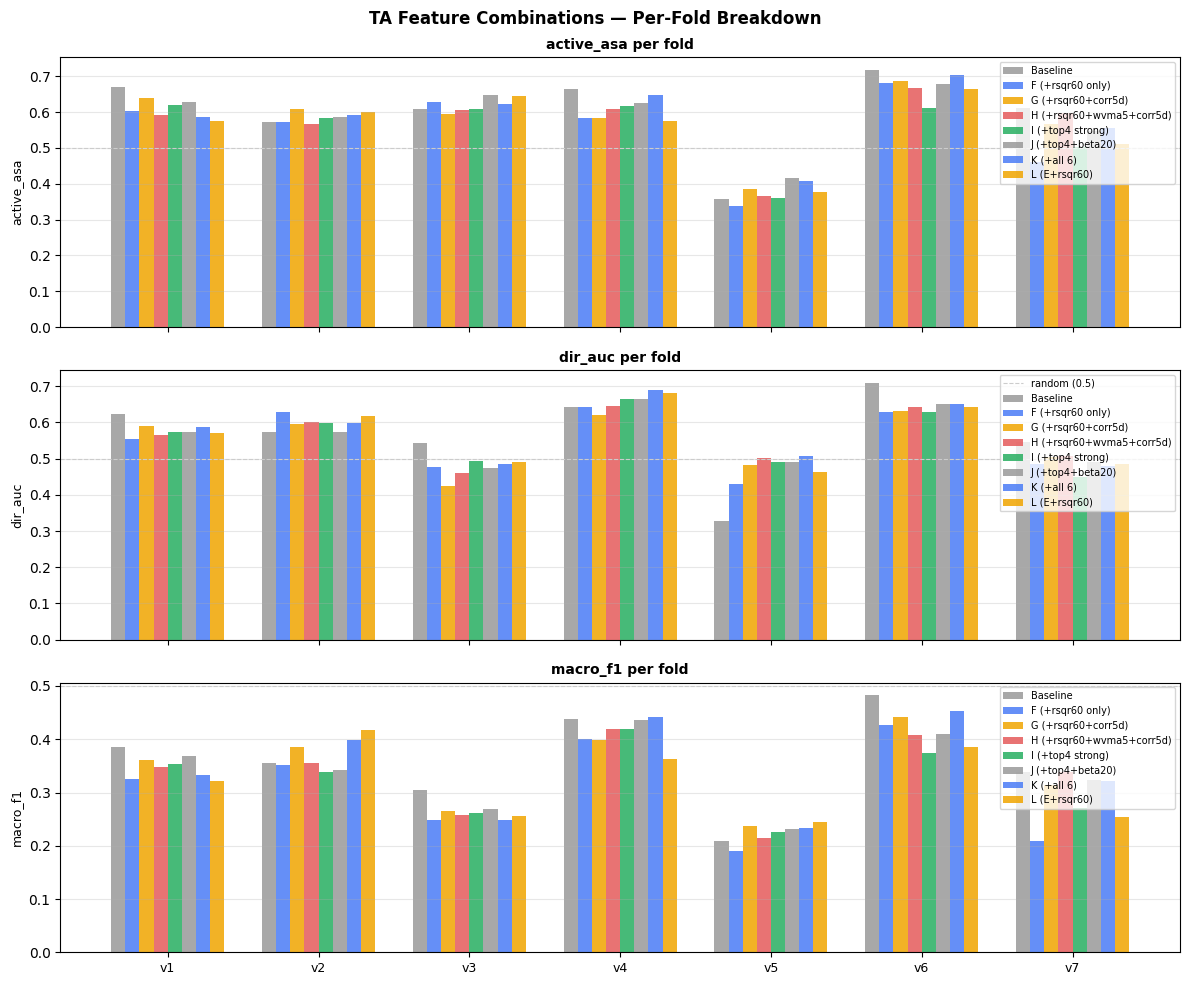

In [9]:
# ── Per-fold breakdown for each combo ────────────────────────────────────────
metrics_to_show = ['active_asa', 'dir_auc', 'macro_f1']
fig, axes = plt.subplots(len(metrics_to_show), 1, figsize=(12, 10), sharex=True)

folds = list(combo_results['Baseline'].index)
x = np.arange(len(folds))
n_combos = len(COMBOS)
w = 0.75 / n_combos
colors = ['#999', '#4a7cf6', '#f0a500', '#e55a5a', '#27ae60']

for ax, metric in zip(axes, metrics_to_show):
    for ci, (combo_name, fold_df) in enumerate(combo_results.items()):
        offset = (ci - n_combos / 2 + 0.5) * w
        vals = fold_df[metric].values
        ax.bar(x + offset, vals, w, label=combo_name,
               color=colors[ci % len(colors)], alpha=0.85)
    ax.axhline(0.5, color='#ccc', linestyle='--', linewidth=0.8, label='random (0.5)' if metric == 'dir_auc' else None)
    ax.set_ylabel(metric, fontsize=9)
    ax.set_title(f'{metric} per fold', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(folds, fontsize=9)
plt.suptitle('TA Feature Combinations — Per-Fold Breakdown', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Hyperparameter Re-search (if a combo beats baseline)

If any combo beats the baseline on **both** ASA and Dir AUC, run the 36-config hyperparameter search on that combo's feature set.  
If multiple combos beat baseline, the one with the highest `Dir AUC` is selected.

In [10]:
BASE_PARAMS = dict(
    learning_rate=0.05, feature_fraction=0.8,
    reg_alpha=0.2, reg_lambda=1.0,
)
HP_GRID = {
    'num_leaves':        [4, 8, 16, 31],
    'min_child_samples': [20, 40, 60],
    'n_estimators':      [80, 120, 200],
}

# ── Override: force HP search on a specific combo regardless of baseline comparison ──
FORCE_HP_COMBO = 'L (E+rsqr60)'   # force HP search on Combo L

bl = summary_df.loc['Baseline']

if FORCE_HP_COMBO:
    print(f'FORCE_HP_COMBO set → running HP search on: {FORCE_HP_COMBO}')
    BEST_COMBO_NAME  = FORCE_HP_COMBO
    BEST_COMBO_FEATS = COMBOS[FORCE_HP_COMBO]
    HP_SEARCH_RUN    = True
else:
    candidates = summary_df[
        (summary_df['Active ASA'] > bl['Active ASA']) &
        (summary_df['Dir AUC']    > bl['Dir AUC'])
    ].copy()
    if candidates.empty:
        print('No combo beats the baseline on both ASA and Dir AUC.')
        print('Hyperparameter search skipped.')
        BEST_COMBO_NAME   = 'Baseline'
        BEST_COMBO_FEATS  = BASE_FEATURES
        BEST_COMBO_PARAMS = LOCKED_PARAMS
        HP_SEARCH_RUN     = False
    else:
        BEST_COMBO_NAME  = candidates['Dir AUC'].idxmax()
        BEST_COMBO_FEATS = COMBOS[BEST_COMBO_NAME]
        HP_SEARCH_RUN    = True

if HP_SEARCH_RUN:
    print(f'Combo     : {BEST_COMBO_NAME} ({len(BEST_COMBO_FEATS)} features)')
    print(f'Running 36-config × {len(E10_FOLDS)}-fold hyperparameter search …\n')

    combos_hp = list(iterproduct(
        HP_GRID['num_leaves'], HP_GRID['min_child_samples'], HP_GRID['n_estimators']
    ))
    hp_rows = []
    for i, (nl, mcs, ne) in enumerate(combos_hp, 1):
        params = {**BASE_PARAMS, 'num_leaves': nl, 'min_child_samples': mcs, 'n_estimators': ne}
        fold_ms = []
        for fold_id, train_end, test_start, test_end in E10_FOLDS:
            tr_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
            te_mask = ((df['date'] >= pd.Timestamp(test_start)) &
                       (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna())
            tr, te = df[tr_mask], df[te_mask]

            x_tr  = tr[BEST_COMBO_FEATS].fillna(tr[BEST_COMBO_FEATS].median())
            y_tr  = label_3class(tr[TARGET].values, threshold=THRESHOLD)
            y_enc = np.array([label_map[v] for v in y_tr], dtype=int)
            clf   = lgb.LGBMClassifier(objective='multiclass', num_class=3,
                                        random_state=42, verbose=-1, n_jobs=1, **params)
            clf.fit(x_tr, y_enc)
            x_te      = te[BEST_COMBO_FEATS].fillna(tr[BEST_COMBO_FEATS].median())
            y_te_cls  = label_3class(te[TARGET].values, threshold=THRESHOLD)
            y_te_cont = te[TARGET].values
            preds_enc = clf.predict(x_te)
            preds     = np.array([inv_map[p] for p in preds_enc])
            proba     = clf.predict_proba(x_te)
            fold_ms.append(offset_metrics(preds, y_te_cls, y_te_cont, te['date'].values, proba=proba))

        agg  = pd.DataFrame(fold_ms).mean()
        comp = 0.6 * float(agg.active_asa) + 0.4 * float(agg.macro_f1)
        hp_rows.append({
            'num_leaves': nl, 'min_child_samples': mcs, 'n_estimators': ne,
            'active_asa': round(float(agg.active_asa), 3),
            'macro_f1':   round(float(agg.macro_f1),   3),
            'dir_auc':    round(float(agg.dir_auc),     3),
            'composite':  round(comp, 4),
        })
        print(f'[{i:2d}/36]  leaves={nl:2d}  mcs={mcs:2d}  ne={ne:3d}  '
              f'asa={agg.active_asa:.3f}  auc={agg.dir_auc:.3f}  composite={comp:.4f}')

    hp_df = pd.DataFrame(hp_rows).sort_values('composite', ascending=False).reset_index(drop=True)
    hp_df.index += 1
    best_hp = hp_df.iloc[0]
    BEST_COMBO_PARAMS = {
        **BASE_PARAMS,
        'num_leaves':        int(best_hp.num_leaves),
        'min_child_samples': int(best_hp.min_child_samples),
        'n_estimators':      int(best_hp.n_estimators),
    }
    print(f'\n── Best hyperparams for {BEST_COMBO_NAME} ──')
    for k, v in BEST_COMBO_PARAMS.items():
        print(f'  {k}: {v}')
    print(f'  ASA: {best_hp.active_asa:.3f}  Dir AUC: {best_hp.dir_auc:.3f}  composite: {best_hp.composite:.4f}')
    print()
    display(hp_df.head(10)[['num_leaves','min_child_samples','n_estimators',
                              'active_asa','dir_auc','macro_f1','composite']])


FORCE_HP_COMBO set → running HP search on: L (E+rsqr60)
Combo     : L (E+rsqr60) (33 features)
Running 36-config × 7-fold hyperparameter search …



[ 1/36]  leaves= 4  mcs=20  ne= 80  asa=0.579  auc=0.545  composite=0.4746


[ 2/36]  leaves= 4  mcs=20  ne=120  asa=0.583  auc=0.543  composite=0.4809


[ 3/36]  leaves= 4  mcs=20  ne=200  asa=0.567  auc=0.539  composite=0.4680


[ 4/36]  leaves= 4  mcs=40  ne= 80  asa=0.584  auc=0.569  composite=0.4857


...

[33/36]  leaves=31  mcs=40  ne=200  asa=0.558  auc=0.562  composite=0.4619


[34/36]  leaves=31  mcs=60  ne= 80  asa=0.559  auc=0.565  composite=0.4678


[35/36]  leaves=31  mcs=60  ne=120  asa=0.557  auc=0.565  composite=0.4624


[36/36]  leaves=31  mcs=60  ne=200  asa=0.558  auc=0.563  composite=0.4652

── Best hyperparams for L (E+rsqr60) ──
  learning_rate: 0.05
  feature_fraction: 0.8
  reg_alpha: 0.2
  reg_lambda: 1.0
  num_leaves: 4
  min_child_samples: 40
  n_estimators: 200
  ASA: 0.592  Dir AUC: 0.570  composite: 0.4950



,num_leaves,min_child_samples,n_estimators,active_asa,dir_auc,macro_f1,composite
1,4,40,200,0.592,0.570,0.349,0.4950
2,4,40,120,0.591,0.573,0.347,0.4933
3,4,60,120,0.585,0.550,0.341,0.4872
4,4,40,80,0.584,0.569,0.338,0.4857
5,4,20,120,0.583,0.543,0.328,0.4809
6,8,20,120,0.581,0.540,0.326,0.4787
7,4,60,80,0.575,0.555,0.329,0.4765
8,4,20,80,0.579,0.545,0.317,0.4746
9,4,60,200,0.568,0.554,0.327,0.4718
10,8,60,80,0.569,0.555,0.323,0.4708


## 9. Final Comparison (best tuned combo vs baseline)

Re-run the winning combo with its best hyperparameters and display the side-by-side.

In [11]:
if HP_SEARCH_RUN:
    print(f'Running final eval: {BEST_COMBO_NAME} with tuned params …')
    best_tuned_results = run_walk_forward(BEST_COMBO_FEATS, params=BEST_COMBO_PARAMS)
else:
    best_tuned_results = combo_results[BEST_COMBO_NAME]

print('\n=== Final Head-to-Head ===')
headers = ['mean_acc', 'macro_f1', 'active_asa', 'dir_auc', 'active_cov']
bl_mean = combo_results['Baseline'].mean()
bt_mean = best_tuned_results.mean()
print(f'{"Metric":<20} {"Baseline":>10} {"Best combo":>12} {"Delta":>8}')
print('-' * 54)
for h in headers:
    delta = float(bt_mean[h]) - float(bl_mean[h])
    print(f'{h:<20} {float(bl_mean[h]):>10.3f} {float(bt_mean[h]):>12.3f} {delta:>+8.3f}')

if HP_SEARCH_RUN:
    d_asa = float(bt_mean.active_asa) - float(bl_mean.active_asa)
    d_auc = float(bt_mean.dir_auc) - float(bl_mean.dir_auc)
    if d_asa > 0 and d_auc > 0:
        print(f'\n→ {BEST_COMBO_NAME} beats baseline on ASA (+{d_asa:.3f}) and Dir AUC (+{d_auc:.3f})')
        print('   Review results above, then set SAVE = True in the next cell to save the artifact.')
    else:
        print('\n→ After hyperparameter tuning, combo does NOT beat baseline on both metrics.')

Running final eval: L (E+rsqr60) with tuned params …



=== Final Head-to-Head ===
Metric                 Baseline   Best combo    Delta
------------------------------------------------------
mean_acc                  0.468        0.453   -0.015
macro_f1                  0.359        0.349   -0.009
active_asa                0.600        0.592   -0.008
dir_auc                   0.566        0.570   +0.003
active_cov                0.943        0.905   -0.038

→ After hyperparameter tuning, combo does NOT beat baseline on both metrics.


## 10. Save Artifact

**Review the results above before running this cell.**  
Set `SAVE = True` only if the best combo genuinely beats the baseline on both ASA and Dir AUC.

In [12]:
SAVE = True    # artifact approved — save Combo E tuned

if not SAVE:
    print('SAVE=False — artifact not saved. Set SAVE=True to save.')
else:
    # Train on ALL available data with best combo + params
    full_df    = df[df[TARGET].notna()].copy()
    train_end  = full_df['date'].max()

    x_full = full_df[BEST_COMBO_FEATS].fillna(full_df[BEST_COMBO_FEATS].median())
    y_full = label_3class(full_df[TARGET].values, threshold=THRESHOLD)
    y_enc  = np.array([label_map[v] for v in y_full], dtype=int)

    final_clf = lgb.LGBMClassifier(
        objective='multiclass', num_class=3,
        random_state=42, verbose=-1, n_jobs=1, **BEST_COMBO_PARAMS
    )
    final_clf.fit(x_full, y_enc)
    print(f'Trained on {len(full_df)} rows  |  {full_df["date"].min().date()} → {train_end.date()}')

    TODAY       = date.today().isoformat()
    ARTIFACT_ID = f'ta_features_{BEST_COMBO_NAME.split()[0].lower()}-{TODAY}'
    PKL_PATH    = EXP_ART_DIR / f'{ARTIFACT_ID}.pkl'
    JSON_PATH   = EXP_ART_DIR / f'{ARTIFACT_ID}.json'

    artifact_out = {
        'model':             final_clf,
        'features':          BEST_COMBO_FEATS,
        'target':            TARGET,
        'threshold':         THRESHOLD,
        'label_map':         label_map,
        'inverse_label_map': inv_map,
        'best_params':       BEST_COMBO_PARAMS,
        'combo_name':        BEST_COMBO_NAME,
        'ta_features_added': [f for f in BEST_COMBO_FEATS if f not in BASE_FEATURES],
        'train_rows':        len(full_df),
        'train_end':         str(train_end.date()),
        'artifact_id':       ARTIFACT_ID,
    }
    with open(PKL_PATH, 'wb') as f:
        pickle.dump(artifact_out, f)

    meta_out = {
        'artifact_id':       ARTIFACT_ID,
        'created':           TODAY,
        'source':            'ta_features_training.ipynb',
        'combo_name':        BEST_COMBO_NAME,
        'ta_features_added': artifact_out['ta_features_added'],
        'n_features':        len(BEST_COMBO_FEATS),
        'best_params':       BEST_COMBO_PARAMS,
        'eval_asa':          float(bt_mean.active_asa),
        'eval_dir_auc':      float(bt_mean.dir_auc),
        'eval_macro_f1':     float(bt_mean.macro_f1),
        'baseline_asa':      float(bl_mean.active_asa),
        'baseline_dir_auc':  float(bl_mean.dir_auc),
        'features':          BEST_COMBO_FEATS,
        'target':            TARGET,
        'threshold':         THRESHOLD,
        'train_rows':        int(len(full_df)),
        'train_end':         str(train_end.date()),
        'artifact_path':     str(PKL_PATH),
    }
    with open(JSON_PATH, 'w') as f:
        json.dump(meta_out, f, indent=2)

    print(f'\nSaved PKL  : {PKL_PATH.name}')
    print(f'Saved JSON : {JSON_PATH.name}')
    print(f'\nRun ta_features_performance.ipynb to get full SHAP analysis.')

Trained on 1285 rows  |  2021-02-25 → 2026-04-09

Saved PKL  : ta_features_l-2026-04-22.pkl
Saved JSON : ta_features_l-2026-04-22.json

Run ta_features_performance.ipynb to get full SHAP analysis.
